# Notebook 1: EDA & Preprocessing
### Stock Sense AI — Time Series Pipeline

In [1]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [2]:
!conda install -c plotly plotly -y

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - plotly
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.



In [3]:
import subprocess
subprocess.run(['pip', 'install', 'plotly', 'statsmodels', '--quiet'], check=True)
print('✅ Packages installed')

✅ Packages installed


In [4]:
import sys
!{sys.executable} -m pip install plotly statsmodels

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1. Download Data

In [15]:
TICKER = 'AAPL'
START  = '2018-01-01'
END    = '2024-12-31'

df = yf.download(TICKER, start=START, end=END)
df.to_csv(f'../data/{TICKER}_raw.csv')
print(f'✅ Downloaded {len(df)} rows')
df.head()

[*********************100%***********************]  1 of 1 completed

✅ Downloaded 1760 rows


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304188,40.313549,39.602269,39.812847,102223600
2018-01-03,40.297157,40.839976,40.233987,40.367350,118071600
2018-01-04,40.484333,40.587282,40.262059,40.369685,89738400
2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000
2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200


## 2. Basic Statistics & Missing Values

In [16]:
print('Shape:', df.shape)
print('Missing:', df.isnull().sum().to_dict())
df['Close'].describe()

Shape: (1760, 5)
Missing: {('Close', 'AAPL'): 0, ('High', 'AAPL'): 0, ('Low', 'AAPL'): 0, ('Open', 'AAPL'): 0, ('Volume', 'AAPL'): 0}


Ticker,AAPL
count,1760.000000
mean,121.664108
std,59.001786
min,33.768074
25%,54.026790
50%,131.293945
75%,168.494415
max,257.612701


## 3. Candlestick + Volume Chart

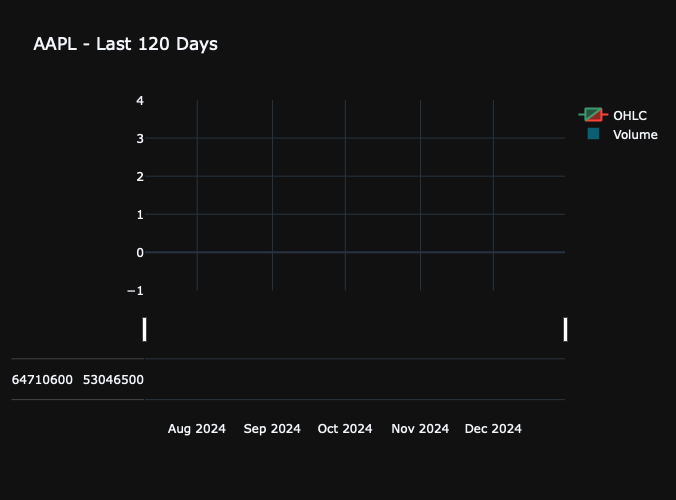

In [17]:
fig = make_subplots(rows=2, cols=1, row_heights=[0.7,0.3], shared_xaxes=True)
fig.add_trace(go.Candlestick(x=df.index[-120:], open=df['Open'][-120:],
    high=df['High'][-120:], low=df['Low'][-120:],
    close=df['Close'][-120:], name='OHLC'), row=1, col=1)
fig.add_trace(go.Bar(x=df.index[-120:], y=df['Volume'][-120:],
    name='Volume', marker_color='rgba(0,212,255,0.4)'), row=2, col=1)
fig.update_layout(title=f'{TICKER} - Last 120 Days', template='plotly_dark', height=500)
fig.show()

## 4. Technical Indicators

In [20]:
close = df['Close'].squeeze() 

# Moving Averages
df['MA_20']  = close.rolling(20).mean()
df['MA_50']  = close.rolling(50).mean()
df['MA_200'] = close.rolling(200).mean()

# RSI
delta = close.diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

# MACD
ema12 = close.ewm(span=12).mean()
ema26 = close.ewm(span=26).mean()
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()

# Bollinger Bands
df['BB_Mid']   = close.rolling(20).mean()
df['BB_Upper'] = df['BB_Mid'] + 2 * close.rolling(20).std()
df['BB_Lower'] = df['BB_Mid'] - 2 * close.rolling(20).std()

print('✅ Indicators computed')
df[['MA_20','RSI','MACD','BB_Upper','BB_Lower']].tail()

✅ Indicators computed


Price,MA_20,RSI,MACD,BB_Upper,BB_Lower
Ticker,,,,,
Date,,,,,
2024-12-23,243.695762,73.865454,5.740452,256.772097,230.619427
2024-12-24,244.955379,76.180690,6.040996,257.981093,231.929666
2024-12-26,246.146869,76.812129,6.272677,259.228955,233.064783
2024-12-27,247.174256,69.300697,6.110582,259.319024,235.029489
2024-12-30,247.913716,58.382099,5.644991,258.954996,236.872436


## 5. ADF Stationarity Test

In [21]:
def adf_test(series, name=''):
    r = adfuller(series.dropna())
    print(f'ADF [{name}]  stat={r[0]:.4f}  p={r[1]:.4f}  {"✅ Stationary" if r[1]<0.05 else "❌ Non-Stationary"}')

adf_test(df['Close'],       'Close')
adf_test(df['Close'].diff().dropna(), '1st Diff')

ADF [Close]  stat=0.0830  p=0.9649  ❌ Non-Stationary
ADF [1st Diff]  stat=-42.5065  p=0.0000  ✅ Stationary


## 6. Seasonal Decomposition

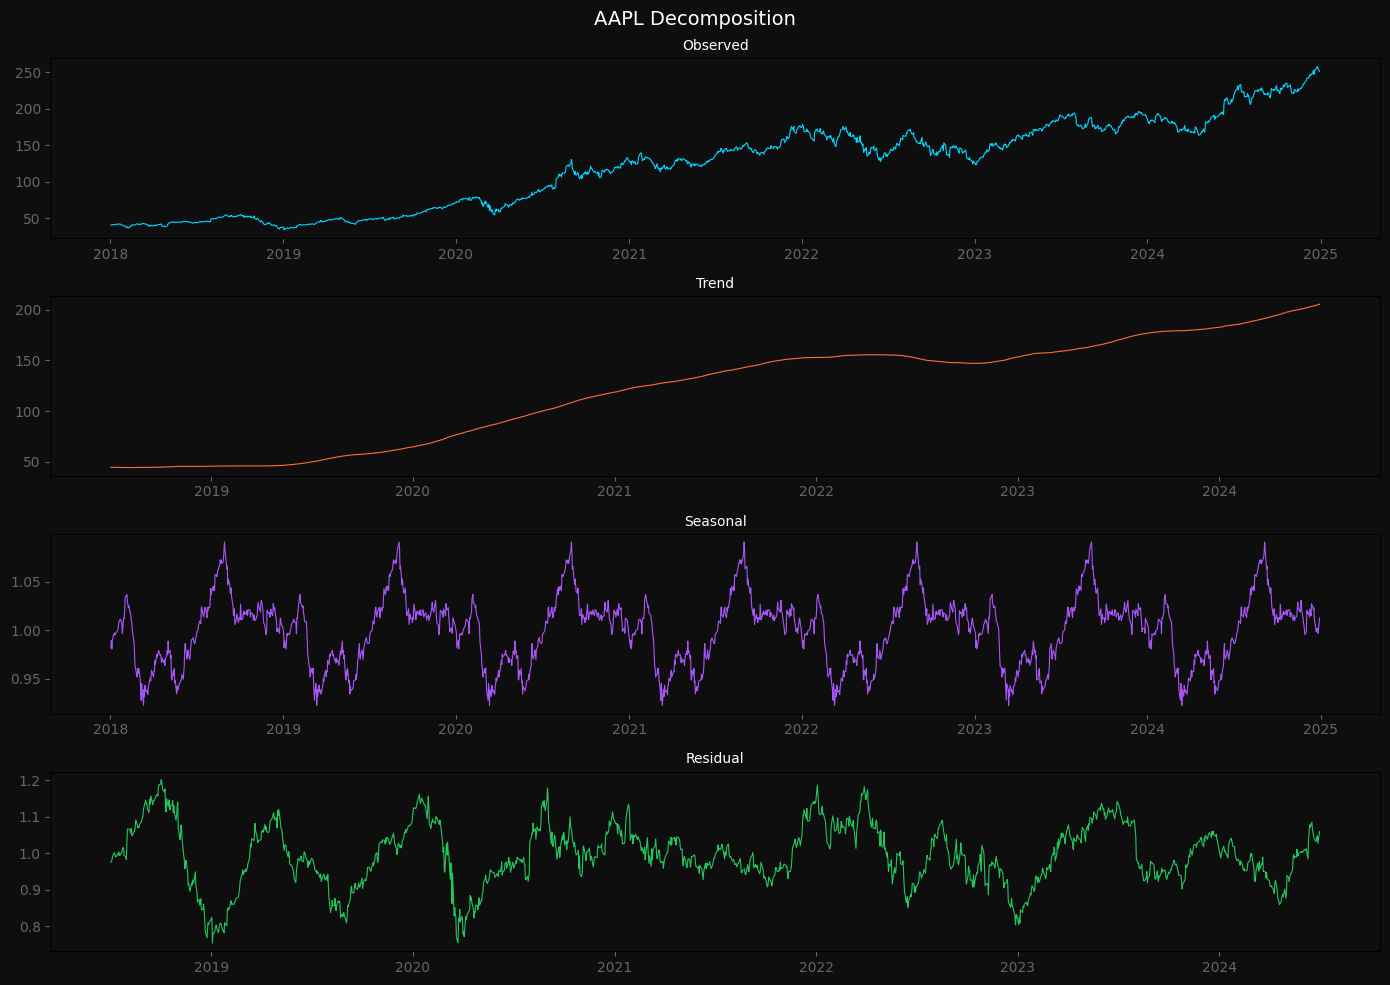

In [22]:
decomp = seasonal_decompose(df['Close'].dropna(), model='multiplicative', period=252)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), facecolor='#0e0e0e')
pairs = [(decomp.observed,'Observed','#00d4ff'),
         (decomp.trend,'Trend','#ff6b35'),
         (decomp.seasonal,'Seasonal','#a855f7'),
         (decomp.resid,'Residual','#22c55e')]
for ax, (data, title, color) in zip(axes, pairs):
    ax.set_facecolor('#0e0e0e')
    ax.plot(data, color=color, linewidth=0.8)
    ax.set_title(title, color='white', fontsize=10)
    ax.tick_params(colors='#666')
plt.suptitle(f'{TICKER} Decomposition', color='white', fontsize=14)
plt.tight_layout()
plt.savefig(f'../data/{TICKER}_decomp.png', dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
plt.show()

## 7. Save Processed Data

In [23]:
cols = ['Open','High','Low','Close','Volume','MA_20','MA_50','MA_200',
        'RSI','MACD','MACD_Signal','BB_Upper','BB_Lower','BB_Mid']
df_clean = df[cols].dropna()
df_clean.to_csv(f'../data/{TICKER}_processed.csv')
print(f'✅ Saved {len(df_clean)} rows → ../data/{TICKER}_processed.csv')

✅ Saved 1561 rows → ../data/AAPL_processed.csv
